In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score


import pandas as pd
import seaborn as sns

UsageError: Line magic function `%seaborn` not found.


## Data and labels 
In this example we know the labels, hence we can test the performances of t-SNE and DBSCAN

In [2]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


## Find the typical minimum distance between points
This yields a typical scale, to be used as a reference for "eps"

[  0.         145.92274307 161.446568   175.02075719 184.83502833
 186.6121665  187.18824319 219.69258419 224.1511747  242.6862013
 284.09295507] range(0, 599)
(11, 600)


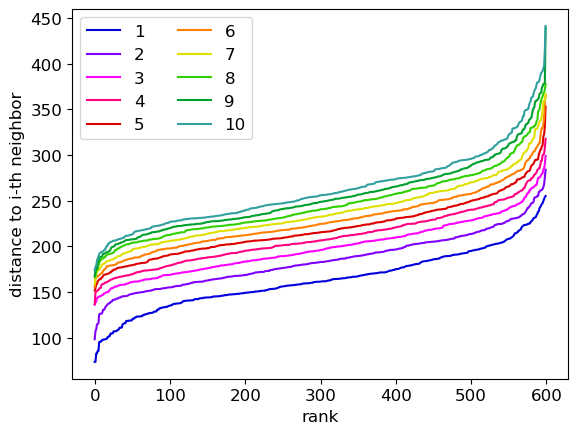

mean minimum distance between nn points:  163.65491354345073


In [3]:
nn = 10
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(x) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(x) # returns distances and indices of nn neighbors
print(d[3,:],range(ind.max()))
dd=d.T # distances to the i-th neighbor for all points, sorted by distance
print(dd.shape)
# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the nearest neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

## t-SNE visualization, for true labels

t-SNE with perplexity=2: 2.6 sec
t-SNE with perplexity=4: 1.8 sec
t-SNE with perplexity=8: 1.8 sec
t-SNE with perplexity=16: 1.9 sec
t-SNE with perplexity=32: 2.4 sec


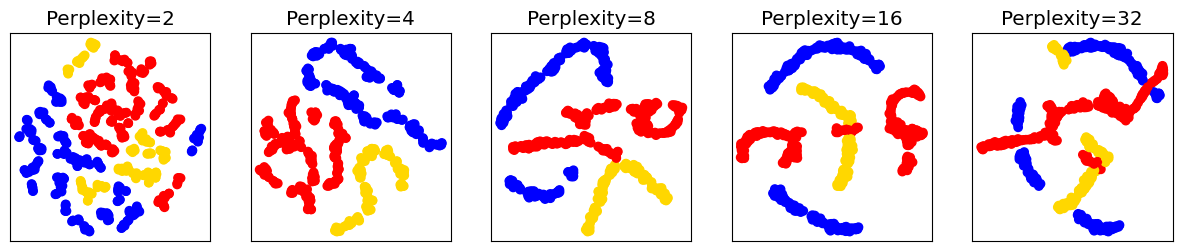

In [4]:
np.random.seed(0)
n_samples = N # number of data points to consider
n_components = 2 # dimension of the embedded space
perplexities = [2, 4, 8, 16, 32]
Np = len(perplexities)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]
for i, perplexity in enumerate(perplexities):
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=0, perplexity=perplexity, learning_rate='auto')
    Y = tsne.fit_transform(data) # apply t-SNE to the data
    t1 = time() # time taken by t-SNE
    print("t-SNE with perplexity=%d: %.2g sec" % (perplexity, t1 - t0))
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap) # plot the t-SNE embedding
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)
    
plt.show()

## Different random initial states (random_state=i)

In [11]:
X_all[1]

array([[ -2.2010798,  29.523714 ],
       [-34.064857 , -72.39555  ],
       [ 40.452732 , -11.351125 ],
       ...,
       [ 32.212753 ,  62.18403  ],
       [-78.62244  ,  10.640315 ],
       [-46.413692 ,  38.66973  ]], dtype=float32)

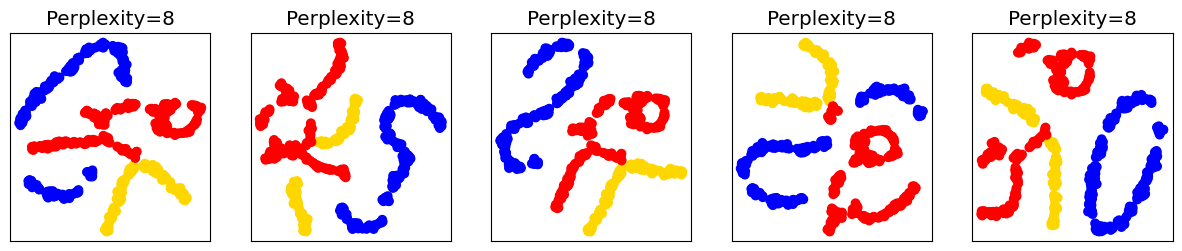

In [ ]:
n_samples = N
n_components = 2 
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]

perplexity= 8

for i in range(5):
    np.random.seed(i) 
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, 
                         init='random',random_state=i, 
                         perplexity=perplexity)
    Y = tsne.fit_transform(data)
    t1 = time()
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap)
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y) # store the t-SNE embedding for later use
    
plt.show()

## DBSCAN: find labels by applying clustering

In [23]:
rows = [1, 2, 3]      # your i values
cols = [10, 20, 30]   # your j values

# create empty dataframe with i as rows, j as columns
df = pd.DataFrame(index=rows, columns=cols, dtype=float)
df.loc[1,10]

nan

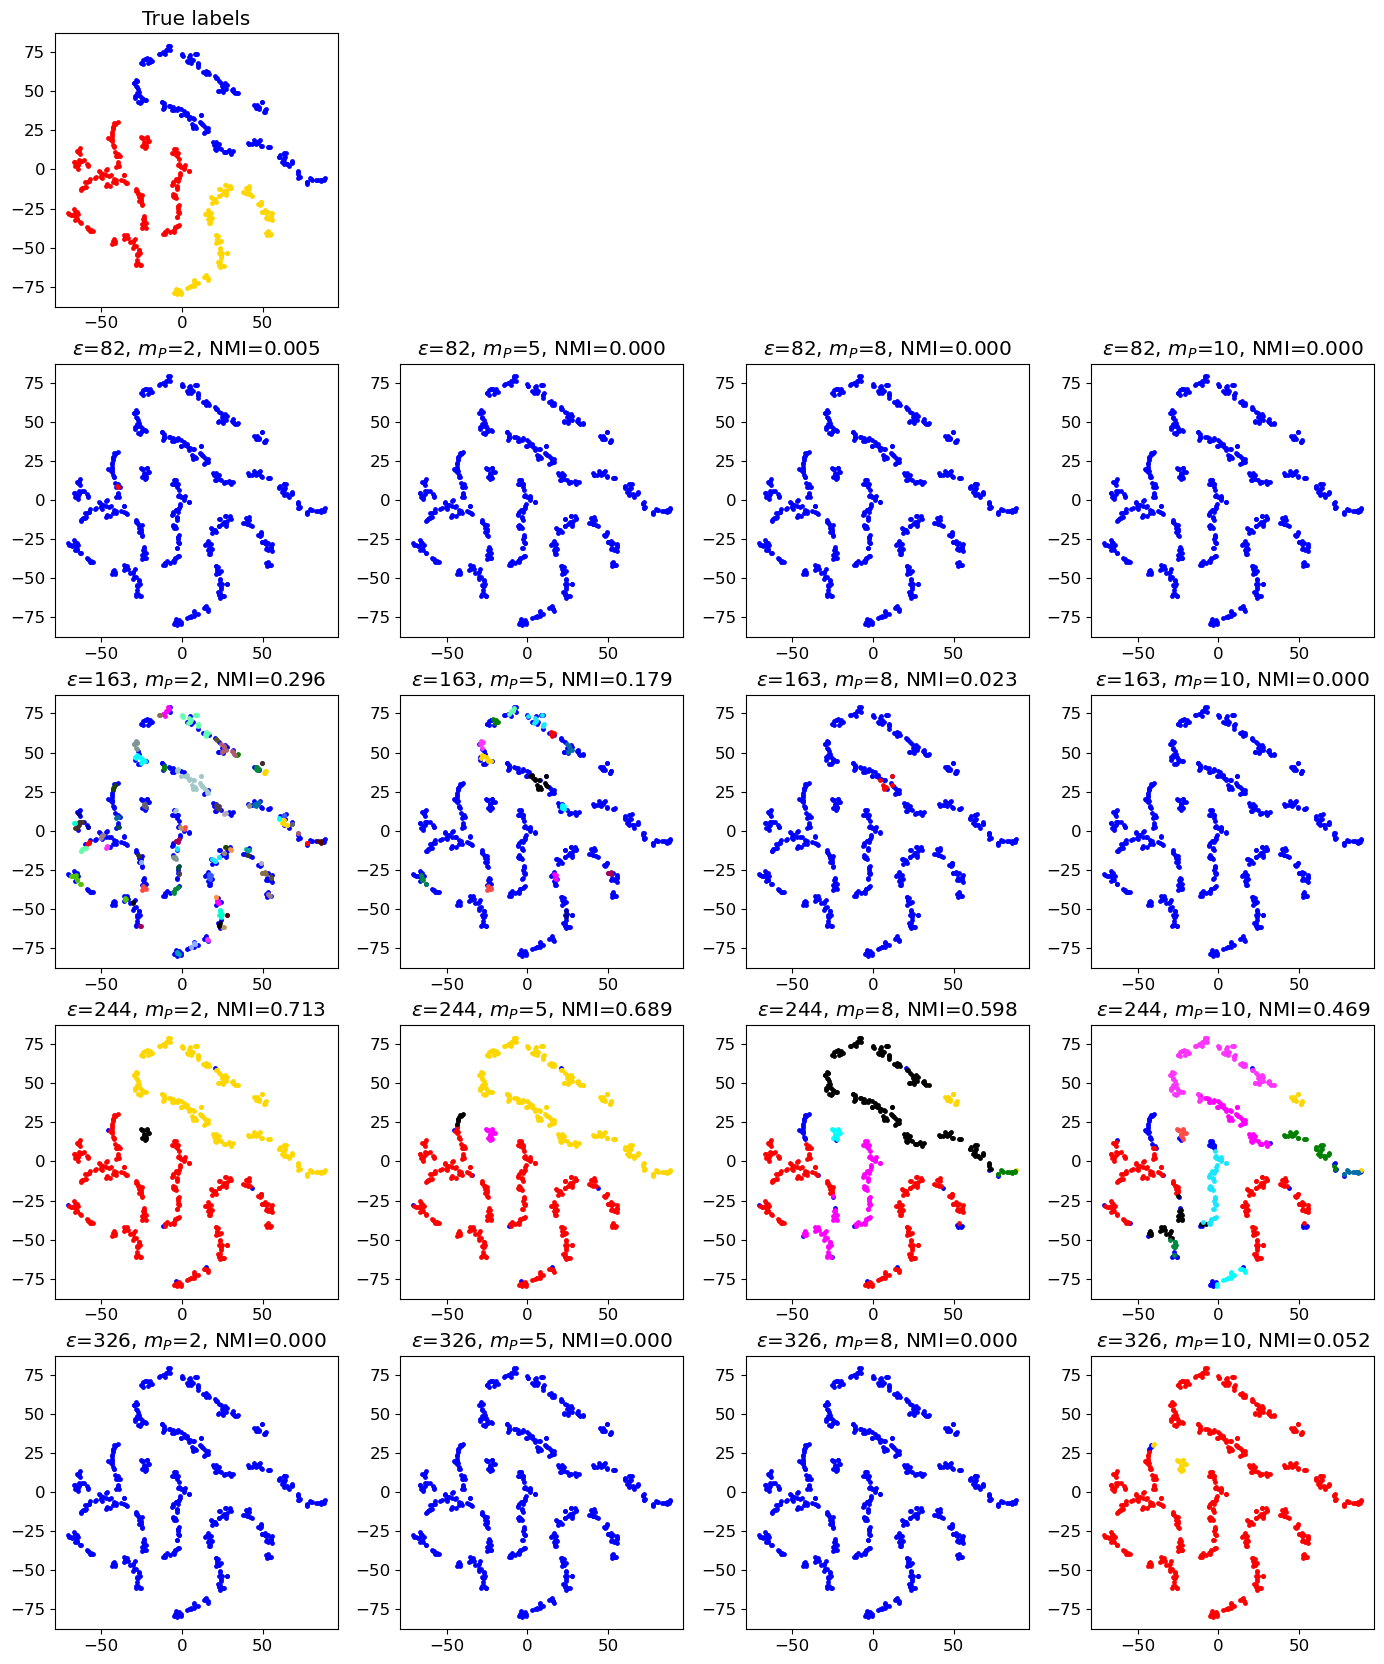

In [26]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
ms = 6

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def plotting_ax(X, y, ax):
    # plotting function
    for i, yu in enumerate(np.unique(y)):
        pos = (y == yu)
        ax.scatter(X[pos,0], X[pos,1],c=cpalette[i%len(cpalette)],s=ms)

# DBSCAN has a few parameters, let's sweep over a few parameters and see what happens
np.random.seed(12345)
n_true_center=3 
#X, ytrue = make_blobs(10000, 2, n_true_center) # Generating random gaussian mixture
X2D = X_all[2] # best(?) visualization of the data in 2D, obtained by t-SNE with perplexity=8
X = data #'''12 dimensional data'''
y_true = y

#eps_range = [0.01,0.1,0.5,1.0,10.]
if mean_min_dist<10:
    r=mean_min_dist # mean minimum distance between nn points
else:
    r = int(mean_min_dist)
eps_range = [r/2,r,1.5*r,2*r] # range of eps values to try

min_sample_range = [2,5,8,10] 
DIMY=len(eps_range) 
DIMX=len(min_sample_range)
fig, ax = plt.subplots(DIMY+1,DIMX,figsize=(14,16.8))

i,j=0,0
nmi=1
plotting_ax(X2D,y,ax[i,j])
ax[i,j].set_title('True labels')
for j in range(1,DIMX): fig.delaxes(ax[i,j])
    


# creating dataframe to store NMI for (eps, min_point) 
# and to be plotted with heatmap

df = pd.DataFrame(index=eps_range, columns=min_sample_range)
    
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        plotting_ax(X2D,y_hat,ax[i+1,j])
        nmi=NMI(y_hat, y_true)
        df.loc[eps, min_samples] = nmi

        ax[i+1,j].set_title(r'$\epsilon$=%.0f, $m_P$=%i, NMI=%.3f'%(eps,min_samples,nmi))

plt.tight_layout(h_pad=0.5)
plt.show()


In [42]:
type(df.loc[326,2])

numpy.float64

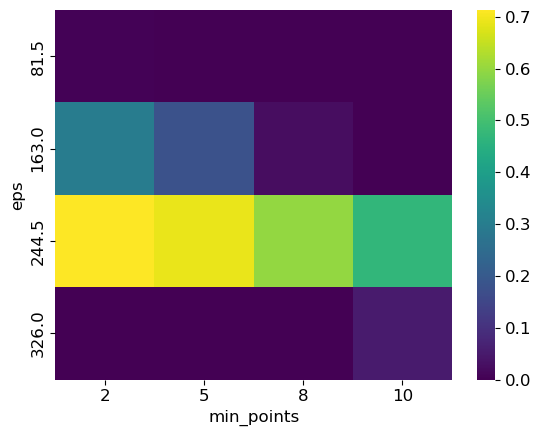

In [56]:
def plot_heatmap(data):
    sns.heatmap(data.astype(float), cmap='viridis')
    plt.xlabel("min_points")
    plt.ylabel("eps")
    plt.show()

plot_heatmap(df)